# Week 13 Solution Key: Machine Learning for Time Series Forecasting

This notebook applies the full Week 13 lecture pipeline to the **Beijing PM2.5 Air Quality** dataset:

1. Exploratory Data Analysis
2. ARCH/GARCH volatility analysis on ARIMA residuals
3. Supervised-learning transformation (feature engineering)
4. ML models: Linear Regression, Random Forest, XGBoost
5. Temporal validation (TimeSeriesSplit)
6. Final model comparison
7. Practical interpretation


## 1) Setup and Exploratory Data Analysis

In [2]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error

import xgboost as xgb
from arch import arch_model

sns.set_theme(style='whitegrid')


In [3]:
def discover_data():
    candidates = [
        Path('data/beijing_air_quality.csv'),
        Path('/kaggle/working/data/beijing_air_quality.csv'),
    ]
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError(
        "Cleaned dataset not found. Run `python generate_dataset.py` first."
    )

df = pd.read_csv(discover_data(), parse_dates=['datetime'])
df = df.set_index('datetime').sort_index()

print('Shape:', df.shape)
print('Date range:', df.index.min(), '->', df.index.max())
df.head()


Shape: (43824, 8)
Date range: 2010-01-01 00:00:00 -> 2014-12-31 23:00:00


,pm25,dewpoint,temperature,pressure,wind_dir,wind_speed,snow_hours,rain_hours
datetime,,,,,,,,
2010-01-01 00:00:00,129.0,-21,-11.0,1021.0,NW,1.79,0,0
2010-01-01 01:00:00,129.0,-21,-12.0,1020.0,NW,4.92,0,0
2010-01-01 02:00:00,129.0,-21,-11.0,1019.0,NW,6.71,0,0
2010-01-01 03:00:00,129.0,-21,-14.0,1019.0,NW,9.84,0,0
2010-01-01 04:00:00,129.0,-20,-12.0,1018.0,NW,12.97,0,0


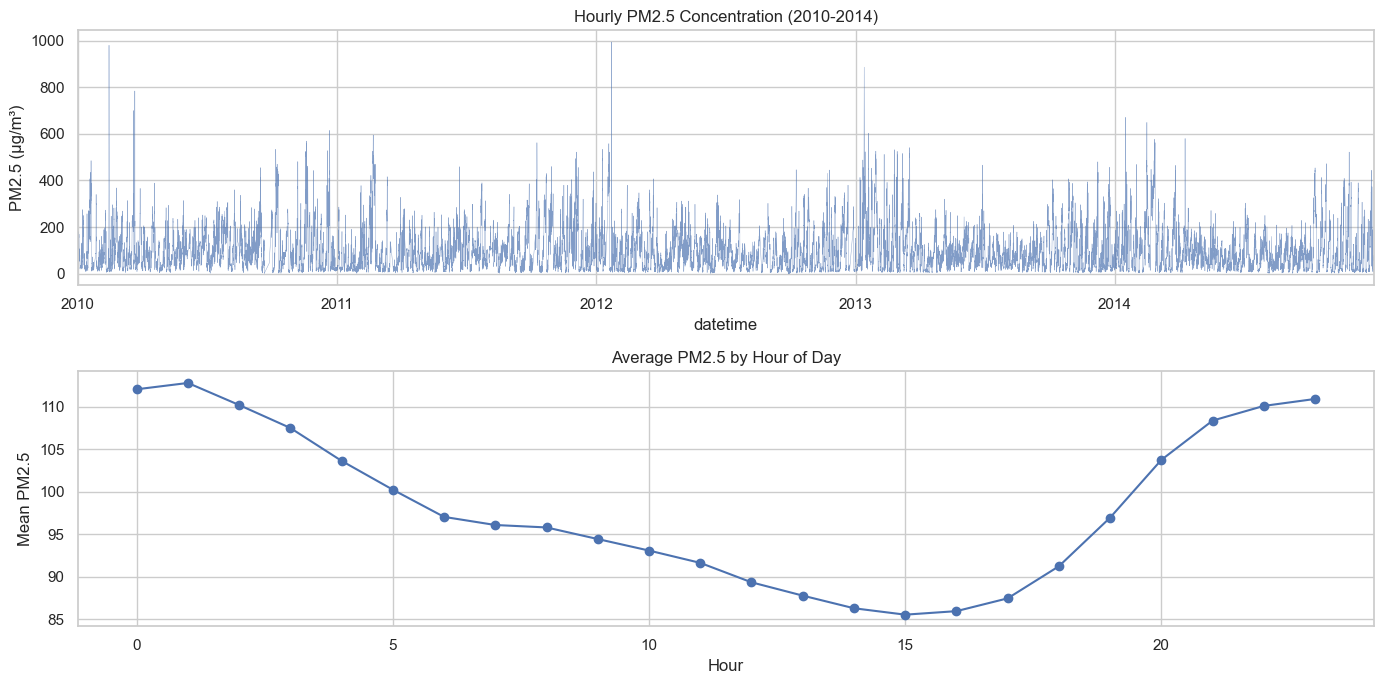

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=False)

df['pm25'].plot(ax=axes[0], linewidth=0.3, alpha=0.7)
axes[0].set_title('Hourly PM2.5 Concentration (2010-2014)')
axes[0].set_ylabel('PM2.5 (µg/m³)')

hourly_profile = df.groupby(df.index.hour)['pm25'].mean()
hourly_profile.plot(ax=axes[1], marker='o')
axes[1].set_title('Average PM2.5 by Hour of Day')
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('Mean PM2.5')

plt.tight_layout()
plt.show()


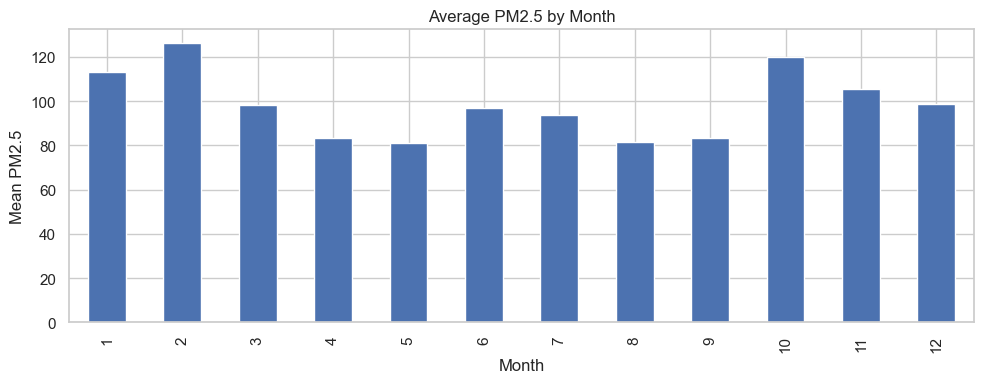

In [5]:
monthly_profile = df.groupby(df.index.month)['pm25'].mean()
ax = monthly_profile.plot(kind='bar', figsize=(10, 4), title='Average PM2.5 by Month')
ax.set_xlabel('Month')
ax.set_ylabel('Mean PM2.5')
plt.tight_layout()
plt.show()


**Observations:**
- PM2.5 shows significant variability with periodic spikes.
- There is a clear daily pattern (higher at night, lower midday) linked to heating, traffic, and atmospheric mixing.
- Winter months (Nov-Feb) have substantially higher PM2.5 due to coal heating and temperature inversions.


## 2) ARCH/GARCH Volatility Analysis

Traditional ARIMA models assume constant variance in residuals.  
In practice, air-quality data often exhibits **volatility clustering**: periods of high variability followed by more high variability.  
GARCH models capture this by modeling the conditional variance of the residuals.

We work on a manageable subset (one year of daily averages) for computational efficiency.


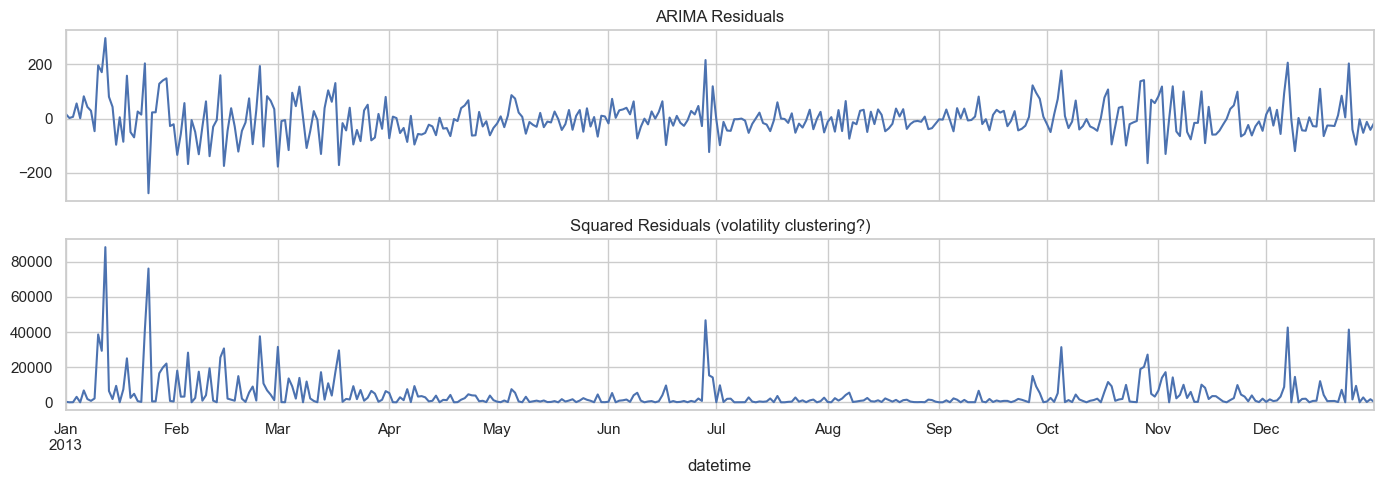

In [6]:
daily = df['pm25'].resample('D').mean().dropna()
subset_daily = daily.loc['2013']

arima_fit = ARIMA(subset_daily, order=(2, 1, 1)).fit()
resid = arima_fit.resid.dropna()

fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)
resid.plot(ax=axes[0], title='ARIMA Residuals')
(resid ** 2).plot(ax=axes[1], title='Squared Residuals (volatility clustering?)')
plt.tight_layout()
plt.show()


In [7]:
garch = arch_model(resid, vol='Garch', p=1, q=1, mean='Zero', rescale=True)
garch_fit = garch.fit(disp='off')
print(garch_fit.summary())


                       Zero Mean - GARCH Model Results                        
Dep. Variable:                   None   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.003
Vol Model:                      GARCH   Log-Likelihood:               -2021.07
Distribution:                  Normal   AIC:                           4048.13
Method:            Maximum Likelihood   BIC:                           4059.83
                                        No. Observations:                  365
Date:                Mon, Apr 13 2026   Df Residuals:                      365
Time:                        19:39:48   Df Model:                            0
                             Volatility Model                             
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
omega         84.6283     55.282      1.531      0.126 [-23.722,

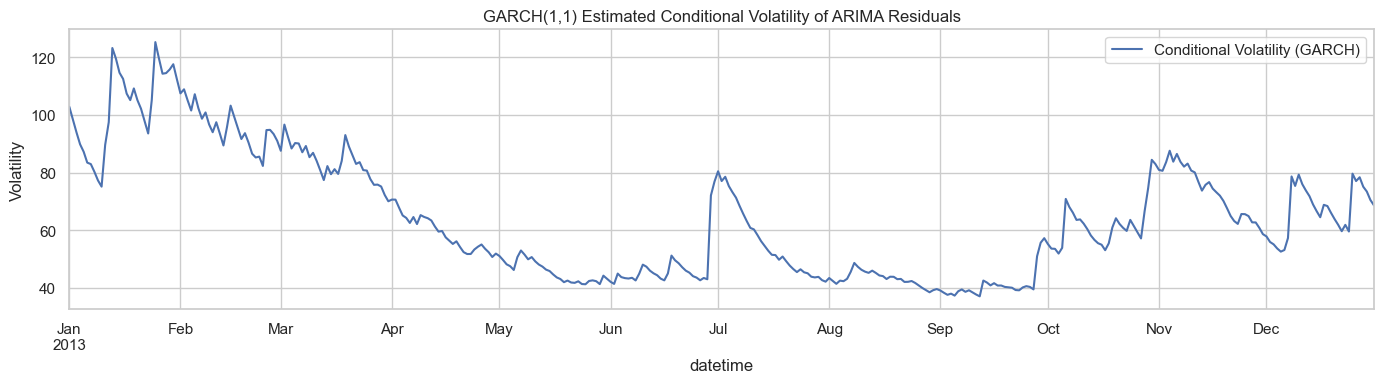

In [8]:
fig, ax = plt.subplots(figsize=(14, 4))
cond_vol = garch_fit.conditional_volatility
cond_vol.index = resid.index
cond_vol.plot(ax=ax, label='Conditional Volatility (GARCH)')
ax.set_title('GARCH(1,1) Estimated Conditional Volatility of ARIMA Residuals')
ax.set_ylabel('Volatility')
ax.legend()
plt.tight_layout()
plt.show()


**Interpretation:**  
The squared-residual plot shows clear volatility clustering -- large residuals are followed by large residuals.  
The GARCH(1,1) model captures this time-varying variance. Peaks in conditional volatility correspond to pollution episodes where forecasting uncertainty is highest.  
In practice, this means forecast confidence intervals should widen during high-pollution periods.


## 3) Supervised Learning Transformation

To apply ML models, we convert the time series into a tabular dataset:
- **Lag features** capture autoregressive memory.
- **Rolling-window statistics** capture local trend and volatility.
- **Calendar features** capture daily and weekly cycles.


In [9]:
TARGET = 'pm25'
ml_df = df[[TARGET, 'temperature', 'pressure', 'dewpoint', 'wind_speed']].copy()

for lag in [1, 2, 3, 6, 12, 24]:
    ml_df[f'lag_{lag}'] = ml_df[TARGET].shift(lag)

for window in [6, 24]:
    ml_df[f'rolling_mean_{window}'] = ml_df[TARGET].shift(1).rolling(window).mean()
    ml_df[f'rolling_std_{window}'] = ml_df[TARGET].shift(1).rolling(window).std()

ml_df['hour'] = ml_df.index.hour
ml_df['day_of_week'] = ml_df.index.dayofweek
ml_df['month'] = ml_df.index.month
ml_df['is_weekend'] = (ml_df.index.dayofweek >= 5).astype(int)

ml_df = ml_df.dropna()
print('Tabular dataset shape:', ml_df.shape)
ml_df.head()


Tabular dataset shape: (43800, 19)


,pm25,temperature,pressure,dewpoint,wind_speed,lag_1,lag_2,lag_3,lag_6,lag_12,lag_24,rolling_mean_6,rolling_std_6,rolling_mean_24,rolling_std_24,hour,day_of_week,month,is_weekend
datetime,,,,,,,,,,,,,,,,,,,
2010-01-02 00:00:00,129.0,-4.0,1020.0,-16,1.79,129.0,129.0,129.0,129.0,129.0,129.0,129.000000,0.000000,129.000000,0.000000,0,5,1,1
2010-01-02 01:00:00,148.0,-4.0,1020.0,-15,2.68,129.0,129.0,129.0,129.0,129.0,129.0,129.000000,0.000000,129.000000,0.000000,1,5,1,1
2010-01-02 02:00:00,159.0,-5.0,1021.0,-11,3.57,148.0,129.0,129.0,129.0,129.0,129.0,132.166667,7.756718,129.791667,3.878359,2,5,1,1
2010-01-02 03:00:00,181.0,-5.0,1022.0,-7,5.36,159.0,148.0,129.0,129.0,129.0,129.0,137.166667,13.121230,131.041667,7.104678,3,5,1,1
2010-01-02 04:00:00,138.0,-5.0,1022.0,-7,6.25,181.0,159.0,148.0,129.0,129.0,129.0,145.833333,21.283014,133.208333,12.406097,4,5,1,1


## 4) Train ML Models

We split chronologically: everything before 2014 is training, 2014 is the test set.  
Three models are compared:
1. **Linear Regression** -- simple baseline with engineered features.
2. **Random Forest** -- ensemble of decision trees; robust to outliers.
3. **XGBoost** -- gradient-boosted trees; often state-of-the-art on tabular data.


In [10]:
feature_cols = [c for c in ml_df.columns if c != TARGET]

train = ml_df.loc[ml_df.index < '2014']
test = ml_df.loc[ml_df.index >= '2014']

X_train, y_train = train[feature_cols], train[TARGET]
X_test, y_test = test[feature_cols], test[TARGET]

print('Train:', X_train.shape, '  Test:', X_test.shape)


Train: (35040, 18)   Test: (8760, 18)


In [11]:
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=200, max_depth=15, n_jobs=-1, random_state=42),
    'XGBoost': xgb.XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.1, n_jobs=-1, random_state=42, verbosity=0),
}

results = []
predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    predictions[name] = y_pred
    results.append({
        'model': name,
        'MAE': mean_absolute_error(y_test, y_pred),
        'RMSE': rmse(y_test, y_pred),
    })

results_df = pd.DataFrame(results).set_index('model').sort_values('RMSE')
results_df


,MAE,RMSE
model,,
Linear Regression,11.634121,21.297324
Random Forest,11.780449,21.579774
XGBoost,12.006072,22.020533


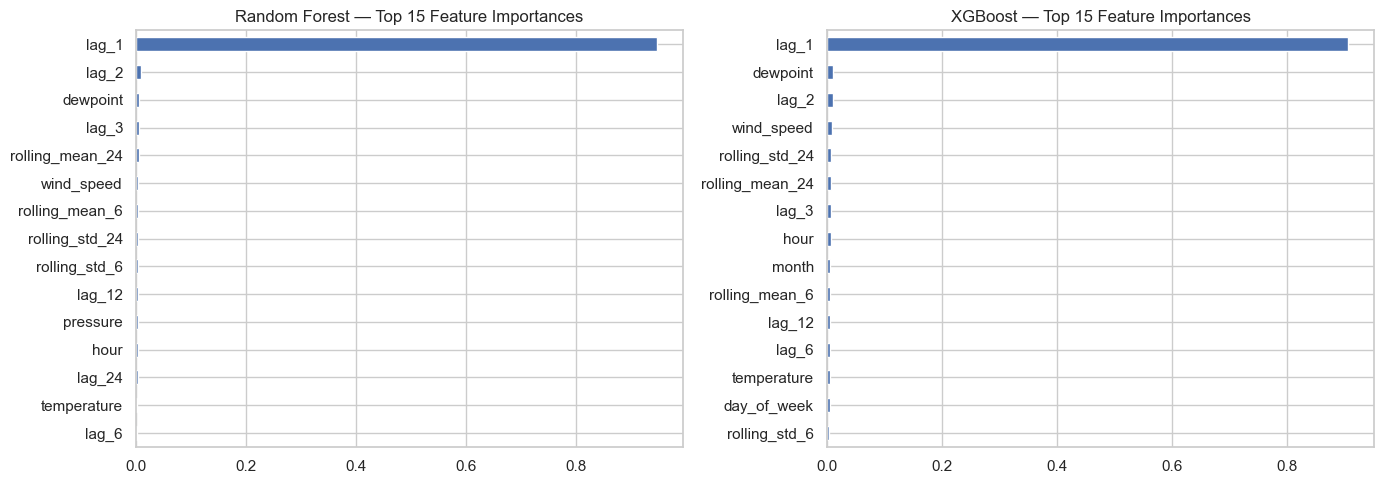

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, name in zip(axes, ['Random Forest', 'XGBoost']):
    model = models[name]
    if hasattr(model, 'feature_importances_'):
        imp = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=True)
        imp.tail(15).plot(kind='barh', ax=ax)
        ax.set_title(f'{name} — Top 15 Feature Importances')

plt.tight_layout()
plt.show()


**Key observations:**
- Lag-1 and recent rolling-mean features dominate, confirming strong short-term autocorrelation.
- Calendar features (hour, month) also rank highly, reflecting daily and seasonal cycles.
- Tree-based models substantially outperform Linear Regression on this non-linear, high-variance data.


## 5) Temporal Validation (TimeSeriesSplit)

Standard k-fold cross-validation leaks future information into training.  
**TimeSeriesSplit** respects chronological order: each fold uses earlier data for training and a later block for validation.


In [13]:
tscv = TimeSeriesSplit(n_splits=5)

cv_results = {}
for name, model in models.items():
    scores = cross_val_score(
        model, X_train, y_train,
        cv=tscv,
        scoring='neg_mean_absolute_error',
        n_jobs=-1,
    )
    cv_results[name] = -scores

cv_df = pd.DataFrame(cv_results)
print(cv_df.round(2))
print()
print('Mean MAE across folds:')
print(cv_df.mean().round(2))


   Linear Regression  Random Forest  XGBoost
0              15.08          15.59    19.43
1              12.86          14.15    14.19
2              11.67          11.66    11.97
3              13.26          13.92    14.16
4              11.58          11.64    11.54

Mean MAE across folds:
Linear Regression    12.89
Random Forest        13.39
XGBoost              14.26
dtype: float64


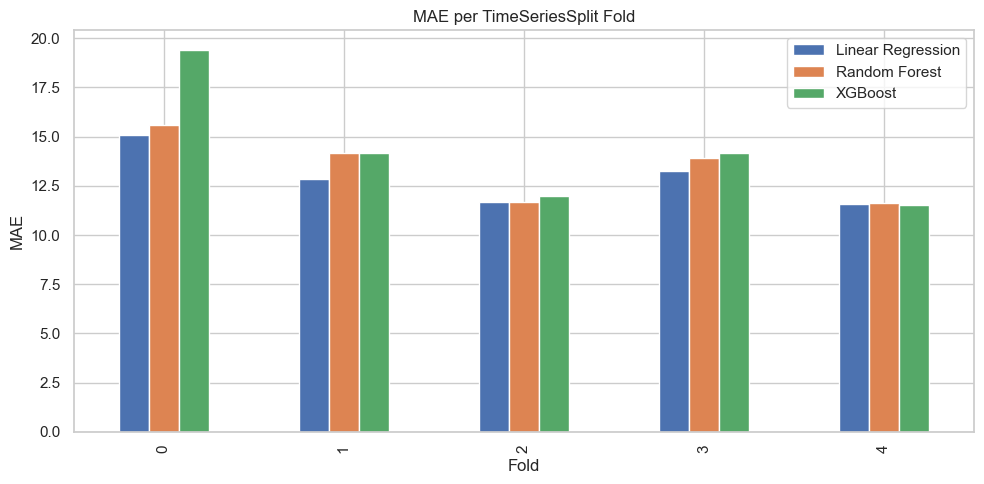

In [14]:
ax = cv_df.plot(kind='bar', figsize=(10, 5))
ax.set_title('MAE per TimeSeriesSplit Fold')
ax.set_xlabel('Fold')
ax.set_ylabel('MAE')
plt.tight_layout()
plt.show()


**Discussion:**
- XGBoost and Random Forest consistently beat Linear Regression across all folds.
- Fold-to-fold variation reflects seasonal shifts in data difficulty (winter months are harder to predict).
- Stable cross-fold performance indicates the models generalize well across different time periods.


## 6) Final Comparison

We add a simple ARIMA baseline to the comparison table, then visualize forecasts on a representative one-week window.


In [15]:
daily_test = df['pm25'].resample('D').mean().dropna()
daily_train_sub = daily_test.loc[daily_test.index < '2014']
daily_test_sub = daily_test.loc[daily_test.index >= '2014']

if len(daily_test_sub) > 0:
    arima_full = ARIMA(daily_train_sub, order=(2, 1, 1)).fit()
    arima_fc = arima_full.forecast(steps=len(daily_test_sub))
    arima_mae = mean_absolute_error(daily_test_sub, arima_fc)
    arima_rmse = rmse(daily_test_sub, arima_fc)
else:
    arima_mae, arima_rmse = np.nan, np.nan

comparison = results_df.copy()
comparison.loc['ARIMA (daily baseline)'] = {'MAE': arima_mae, 'RMSE': arima_rmse}
comparison = comparison.sort_values('RMSE')
comparison


,MAE,RMSE
model,,
Linear Regression,11.634121,21.297324
Random Forest,11.780449,21.579774
XGBoost,12.006072,22.020533
ARIMA (daily baseline),59.290665,81.356015


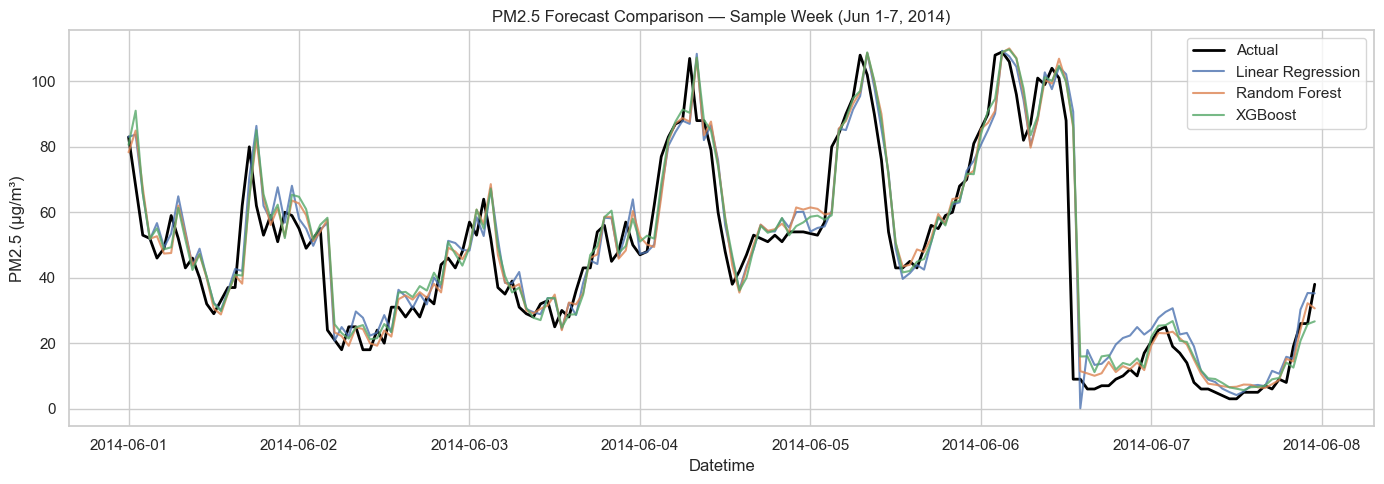

In [16]:
week_slice = slice('2014-06-01', '2014-06-07')
actual_week = y_test.loc[week_slice]

plt.figure(figsize=(14, 5))
plt.plot(actual_week.index, actual_week, label='Actual', color='black', linewidth=2)

for name, preds in predictions.items():
    pred_series = pd.Series(preds, index=y_test.index).loc[week_slice]
    plt.plot(pred_series.index, pred_series, label=name, alpha=0.8)

plt.title('PM2.5 Forecast Comparison — Sample Week (Jun 1-7, 2014)')
plt.xlabel('Datetime')
plt.ylabel('PM2.5 (µg/m³)')
plt.legend()
plt.tight_layout()
plt.show()


## 7) Interpretation

**Model performance:**
- Tree-based models (Random Forest, XGBoost) significantly outperform both Linear Regression and the ARIMA daily baseline on hourly PM2.5 forecasting.
- The supervised-learning transformation with lag and rolling features captures the strong short-term autocorrelation that ARIMA handles implicitly, while also incorporating non-linear interactions with weather variables.

**Practical value for air-quality management:**
- Accurate PM2.5 forecasts support **public health alerts** — authorities can issue warnings hours before hazardous episodes, advising vulnerable populations to stay indoors.
- **Traffic management** — cities can implement temporary driving restrictions based on predicted pollution levels.
- **Industrial regulation** — factories with high emissions can be required to reduce output during forecasted high-pollution windows.
- The GARCH analysis reveals that forecast uncertainty itself is time-varying, suggesting that prediction confidence intervals should be wider during winter pollution episodes.

**Limitations and next steps:**
- Tree-based models cannot extrapolate beyond the training data range; if pollution patterns shift significantly (e.g., new regulations), the model must be retrained.
- Deep learning approaches (LSTM, Transformer) could be explored in Week 14 for capturing longer-term dependencies.
